Saving UAQTEresponses.csv to UAQTEresponses.csv


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.



K-Means
Silhouette Score: 0.012
Davies-Bouldin Index: 7.030
# Interpretation: Weak clustering
# DBI Interpretation: Poor separation

Hierarchical
Silhouette Score: 0.026
Davies-Bouldin Index: 4.142
# Interpretation: Weak clustering
# DBI Interpretation: Poor separation

DBSCAN: Cannot evaluate (noise or single cluster)

GMM
Silhouette Score: 0.012
Davies-Bouldin Index: 7.030
# Interpretation: Weak clustering
# DBI Interpretation: Poor separation

Cohesion: 0.949
Separation: 0.262
Dunn Index: 0.492
WCSS: 185.155


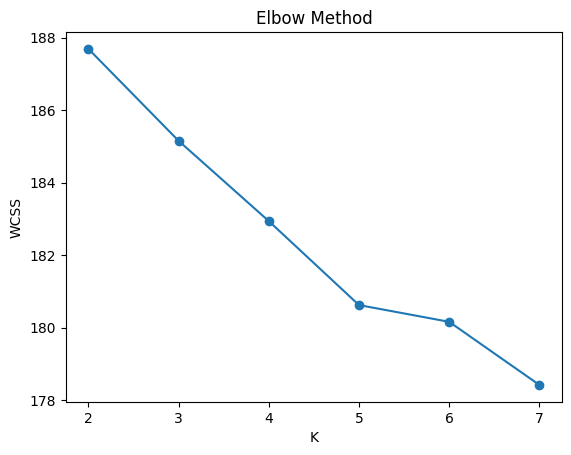


Cluster Labels: {np.int32(0): 'free / help / tuition', np.int32(1): 'good / beneficiary / uaqte', np.int32(2): 'helped / able / college'}


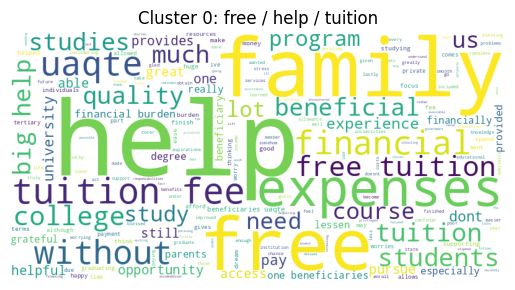

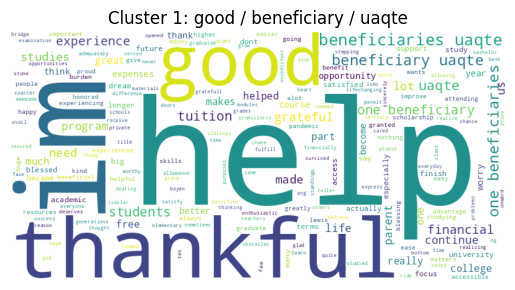

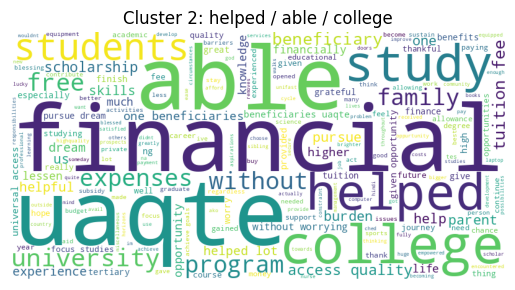

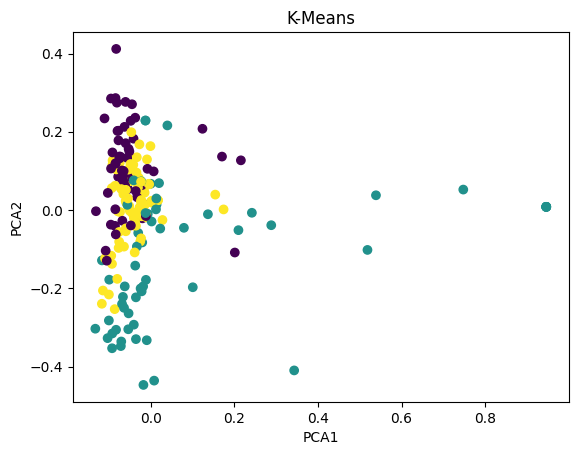

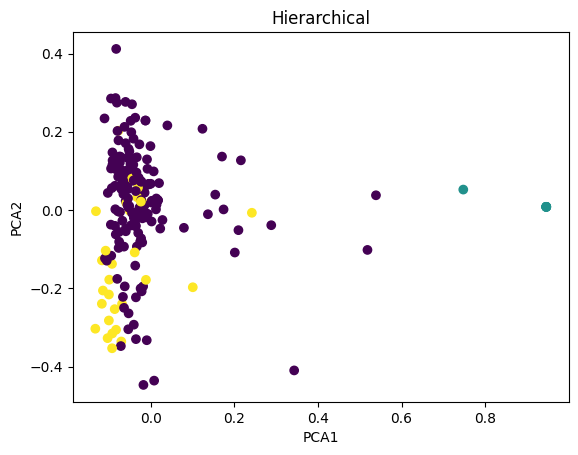

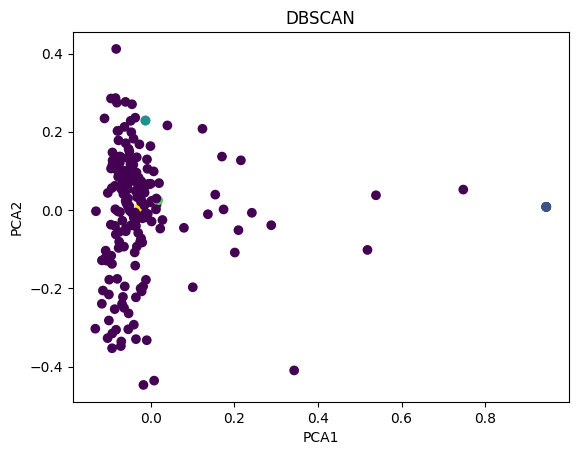

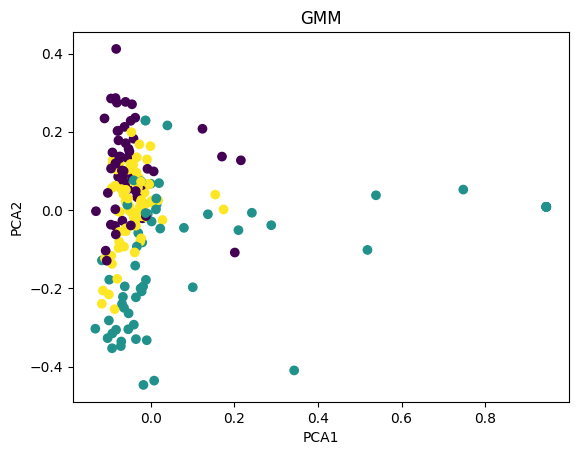

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


DONE!


In [1]:
# ============================================================
# TEXT CLUSTERING PIPELINE
# Dataset: UAQTEResponse
# ============================================================

# -----------------------------
# STEP 0: Install libraries
# -----------------------------
!pip install nltk scikit-learn wordcloud matplotlib chardet scipy

# -----------------------------
# STEP 1: Upload CSV
# -----------------------------
from google.colab import files
uploaded = files.upload()
file_name = list(uploaded.keys())[0]

# -----------------------------
# STEP 2: Load dataset
# -----------------------------
import pandas as pd

try:
    df = pd.read_csv(file_name, encoding='utf-8')
except:
    try:
        df = pd.read_csv(file_name, encoding='cp1252')
    except:
        df = pd.read_csv(file_name, encoding='latin-1')

texts = df['response'].astype(str)

# -----------------------------
# STEP 3: Text Preprocessing
# -----------------------------
import nltk, re
from nltk.corpus import stopwords

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

# Optional custom stopwords
stop_words.update(['student','school','education'])

def preprocess(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = text.split()
    tokens = [w for w in tokens if w not in stop_words]
    return " ".join(tokens)

cleaned_texts = texts.apply(preprocess)

# -----------------------------
# STEP 4: TF-IDF Vectorization
# -----------------------------
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=500, ngram_range=(1,2))
X = vectorizer.fit_transform(cleaned_texts)

# -----------------------------
# STEP 5: Clustering Algorithms
# -----------------------------
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture

kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_labels = kmeans.fit_predict(X)

hier = AgglomerativeClustering(n_clusters=3)
hier_labels = hier.fit_predict(X.toarray())

dbscan = DBSCAN(eps=0.5, min_samples=2)
db_labels = dbscan.fit_predict(X.toarray())

gmm = GaussianMixture(n_components=3, random_state=42)
gmm_labels = gmm.fit_predict(X.toarray())

# Save results
df['kmeans'] = kmeans_labels
df['hierarchical'] = hier_labels
df['dbscan'] = db_labels
df['gmm'] = gmm_labels

# -----------------------------
# STEP 6: Standard Evaluation
# -----------------------------
from sklearn.metrics import silhouette_score, davies_bouldin_score

def evaluate(name, labels):
    unique = set(labels)
    if len(unique) > 1 and -1 not in unique:
        sil = silhouette_score(X, labels)
        dbi = davies_bouldin_score(X.toarray(), labels)

        print(f"\n{name}")
        print(f"Silhouette Score: {sil:.3f}")
        print(f"Davies-Bouldin Index: {dbi:.3f}")

        if sil > 0.7:
            print("# Interpretation: Strong clustering")
        elif sil > 0.5:
            print("# Interpretation: Reasonable clustering")
        else:
            print("# Interpretation: Weak clustering")

        if dbi < 1:
            print("# DBI Interpretation: Good separation")
        else:
            print("# DBI Interpretation: Poor separation")
    else:
        print(f"\n{name}: Cannot evaluate (noise or single cluster)")

evaluate("K-Means", kmeans_labels)
evaluate("Hierarchical", hier_labels)
evaluate("DBSCAN", db_labels)
evaluate("GMM", gmm_labels)

# -----------------------------
# STEP 7: Advanced Evaluation
# -----------------------------
import numpy as np
from scipy.spatial.distance import cdist

X_dense = X.toarray()

def compute_cohesion(X, labels):
    vals = []
    for c in np.unique(labels):
        if c == -1:
            continue
        pts = X[labels == c]
        centroid = pts.mean(axis=0)
        dist = np.linalg.norm(pts - centroid, axis=1)
        vals.append(dist.mean())
    return np.mean(vals)

cohesion = compute_cohesion(X_dense, kmeans_labels)
print("\nCohesion:", round(cohesion, 3))

def compute_separation(X, labels):
    centroids = []
    for c in np.unique(labels):
        if c == -1:
            continue
        centroids.append(X[labels == c].mean(axis=0))
    centroids = np.array(centroids)

    dist = cdist(centroids, centroids)
    np.fill_diagonal(dist, np.inf)
    return np.min(dist)

separation = compute_separation(X_dense, kmeans_labels)
print("Separation:", round(separation, 3))

def compute_dunn(X, labels):
    clusters = [X[labels == c] for c in np.unique(labels) if c != -1]

    min_inter = np.inf
    for i in range(len(clusters)):
        for j in range(i+1, len(clusters)):
            min_inter = min(min_inter, cdist(clusters[i], clusters[j]).min())

    max_intra = 0
    for cluster in clusters:
        if len(cluster) > 1:
            max_intra = max(max_intra, cdist(cluster, cluster).max())

    return min_inter / max_intra if max_intra > 0 else 0

dunn = compute_dunn(X_dense, kmeans_labels)
print("Dunn Index:", round(dunn, 3))

def compute_wcss(X, labels):
    total = 0
    for c in np.unique(labels):
        if c == -1:
            continue
        pts = X[labels == c]
        centroid = pts.mean(axis=0)
        total += ((pts - centroid) ** 2).sum()
    return total

wcss = compute_wcss(X_dense, kmeans_labels)
print("WCSS:", round(wcss, 3))

# -----------------------------
# STEP 8: Elbow Method
# -----------------------------
import matplotlib.pyplot as plt

wcss_vals = []
K_range = range(2, 8)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X)
    wcss_vals.append(km.inertia_)

plt.figure()
plt.plot(K_range, wcss_vals, marker='o')
plt.title("Elbow Method")
plt.xlabel("K")
plt.ylabel("WCSS")
plt.show()

# -----------------------------
# STEP 9: Auto-label Clusters
# -----------------------------
def get_keywords(X, labels, vectorizer, n=5):
    terms = vectorizer.get_feature_names_out()
    result = {}

    for c in np.unique(labels):
        if c == -1:
            continue
        idx = np.where(labels == c)[0]
        mean = X[idx].mean(axis=0).A1
        top = mean.argsort()[::-1][:n]
        result[c] = [terms[i] for i in top]

    return result

keywords = get_keywords(X, kmeans_labels, vectorizer)
labels_map = {c: " / ".join(w[:3]) for c, w in keywords.items()}

df['kmeans_label'] = df['kmeans'].map(labels_map)
print("\nCluster Labels:", labels_map)

# -----------------------------
# STEP 10: Word Clouds
# -----------------------------
from wordcloud import WordCloud

def plot_wc(texts, title):
    wc = WordCloud(width=800, height=400, background_color='white').generate(" ".join(texts))
    plt.figure()
    plt.imshow(wc)
    plt.axis('off')
    plt.title(title)
    plt.show()

for c in labels_map:
    plot_wc(cleaned_texts[df['kmeans'] == c], f"Cluster {c}: {labels_map[c]}")

# -----------------------------
# STEP 11: PCA Visualization
# -----------------------------
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_reduced = pca.fit_transform(X_dense)

def plot_clusters(labels, title):
    plt.figure()
    plt.scatter(X_reduced[:, 0], X_reduced[:, 1], c=labels)
    plt.title(title)
    plt.xlabel("PCA1")
    plt.ylabel("PCA2")
    plt.show()

plot_clusters(kmeans_labels, "K-Means")
plot_clusters(hier_labels, "Hierarchical")
plot_clusters(db_labels, "DBSCAN")
plot_clusters(gmm_labels, "GMM")

# -----------------------------
# STEP 12: Save Output
# -----------------------------
output_file = "clustered_results.csv"
df.to_csv(output_file, index=False)
files.download(output_file)

print("\nDONE!")